In [11]:
import numpy as np
import string
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

In [12]:
# load date
glu_for_high_D_var_gen      = np.load("glu_for_high_D_var_gen.npy")
glu_for_high_D_var_spec     = np.load("glu_for_high_D_var_spec.npy")
glu_for_low_D_var_gen       = np.load("glu_for_low_D_var_gen.npy")
glu_for_low_D_var_spec      = np.load("glu_for_low_D_var_spec.npy")

glu_ox_high_D_var_gen      = np.load("glu_ox_high_D_var_gen.npy")
glu_ox_high_D_var_spec     = np.load("glu_ox_high_D_var_spec.npy")
glu_ox_low_D_var_gen       = np.load("glu_ox_low_D_var_gen.npy")
glu_ox_low_D_var_spec      = np.load("glu_ox_low_D_var_spec.npy")

glu_ac_high_D_var_gen      = np.load("glu_ac_high_D_var_gen.npy")
glu_ac_high_D_var_spec     = np.load("glu_ac_high_D_var_spec.npy")
glu_ac_low_D_var_gen       = np.load("glu_ac_low_D_var_gen.npy")
glu_ac_low_D_var_spec      = np.load("glu_ac_low_D_var_spec.npy")

# reference data for parameter
f_eD1_vals = np.arange(0.1, 1.0, 0.05)   # 0.0, 0.1, …, 1.0
rK1_K2_vals = np.logspace(-2, 2, 5)               # biologically relevant range, considering that K_glu is the reference value

In [13]:
def combine_survival(var_spec, var_gen):
    return var_spec + 2 * var_gen

# this makes it such that each spot in the matrix indicates:
# 0 = generalist never survives
# 1 = generalist survives only in scenario 1, in comparison to the glucose specialist
# 2 = generalist survives only in scenario 2
# 3 = generalist survives either way

In [14]:
# Load matrices
matrices = {
    "glu_for_high": (
        np.load("glu_for_high_D_var_gen.npy"),
        np.load("glu_for_high_D_var_spec.npy")
    ),
    "glu_for_low": (
        np.load("glu_for_low_D_var_gen.npy"),
        np.load("glu_for_low_D_var_spec.npy")
    ),
    "glu_ox_high": (
        np.load("glu_ox_high_D_var_gen.npy"),
        np.load("glu_ox_high_D_var_spec.npy")
    ),
    "glu_ox_low": (
        np.load("glu_ox_low_D_var_gen.npy"),
        np.load("glu_ox_low_D_var_spec.npy")
    ),
    "glu_ac_high": (
        np.load("glu_ac_high_D_var_gen.npy"),
        np.load("glu_ac_high_D_var_spec.npy")
    ),
    "glu_ac_low": (
        np.load("glu_ac_low_D_var_gen.npy"),
        np.load("glu_ac_low_D_var_spec.npy")
    ),
}


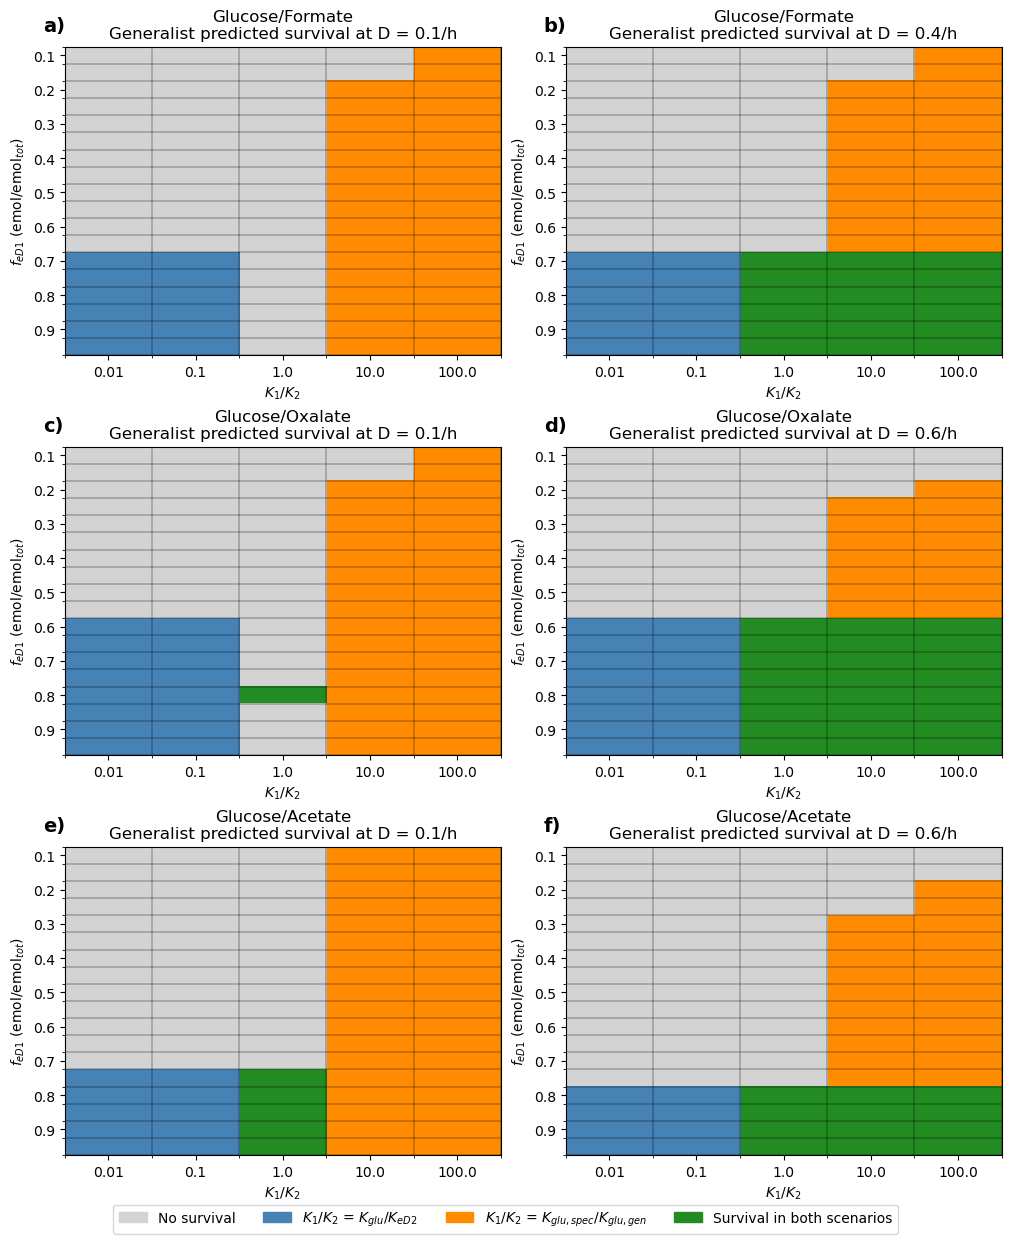

In [15]:
# Create cell edges once
x_edges = np.sqrt(rK1_K2_vals[:-1] * rK1_K2_vals[1:])
x_edges = np.concatenate((
    [rK1_K2_vals[0]**2 / x_edges[0]],
    x_edges,
    [rK1_K2_vals[-1]**2 / x_edges[-1]]
))

y_edges = np.concatenate((
    [f_eD1_vals[0] - (f_eD1_vals[1]-f_eD1_vals[0])/2],
    (f_eD1_vals[:-1] + f_eD1_vals[1:]) / 2,
    [f_eD1_vals[-1] + (f_eD1_vals[-1]-f_eD1_vals[-2])/2]
))

# Discrete colors
cmap = ListedColormap([
    "lightgrey",  
    "steelblue",   
    "darkorange",  
    "forestgreen"  
])

norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)


# Order of plots
plot_order = [
    ("glu_for_low", "Glucose/Formate\nGeneralist predicted survival at D = 0.1/h"),
    ("glu_for_high", "Glucose/Formate\nGeneralist predicted survival at D = 0.4/h"),
    ("glu_ox_low", "Glucose/Oxalate\nGeneralist predicted survival at D = 0.1/h"),
    ("glu_ox_high", "Glucose/Oxalate\nGeneralist predicted survival at D = 0.6/h"),
    ("glu_ac_low", "Glucose/Acetate\nGeneralist predicted survival at D = 0.1/h"),
    ("glu_ac_high", "Glucose/Acetate\nGeneralist predicted survival at D = 0.6/h"),
]


fig, axes = plt.subplots(
    3, 2,
    figsize=(10, 12),
    constrained_layout=True
)


for i, (ax, (name, title)) in enumerate(zip(axes.flat, plot_order)):

    survival_map = (
        matrices[name][1] +
        2 * matrices[name][0]
    )

    ax.imshow(
        survival_map,
        cmap=cmap,
        norm=norm,
        aspect="auto",
        origin="upper"
    )

    ax.set_title(title)

    # place ticks at the actual tested values
    ax.set_xticks(range(len(rK1_K2_vals)))
    ax.set_xticklabels(rK1_K2_vals)

    # Show only selected y-axis labels
    ytick_indices = np.arange(0, len(f_eD1_vals), 2)  # every second value

    ax.set_yticks(ytick_indices)
    ax.set_yticklabels(
        np.round(f_eD1_vals[ytick_indices], 2))

    ax.set_xlabel(r"$K_1/K_2$")
    ax.set_ylabel(r"$f_{eD1}$ (emol/emol$_{tot}$)")

    # grid lines between cells
    ax.set_xticks(np.arange(-0.5, len(rK1_K2_vals), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(f_eD1_vals), 1), minor=True)

    ax.grid(
        which="minor",
        color="black",
        linewidth=0.3,
        #zorder=10
    )

    # Add subplot label (a), (b), (c), ...
    ax.text(
        -0.05, 1.10,
        f"{string.ascii_lowercase[i]})",
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left"
    )


# Legend
legend_elements = [
    mpatches.Patch(color="lightgrey", label="No survival"),
    mpatches.Patch(color="steelblue", label="$K_1$/$K_2$ = $K_{glu}$/$K_{eD2}$"),
    mpatches.Patch(color="darkorange", label="$K_1$/$K_2$ = $K_{glu,spec}$/$K_{glu,gen}$"),
    mpatches.Patch(color="forestgreen", label="Survival in both scenarios"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.03)
)

plt.show()